# Cytotoxicity Dataset: Statistical Analysis & Visualization

A data-only deep dive into `data/combined/combined_cytotoxicity_classification.csv` — no
modeling here (see `eda_and_baselines.ipynb` for baselines). The goal is to actually understand
what's in this dataset: data quality, class balance, chemical-space coverage, and which molecular
properties statistically associate with the cytotoxicity label, each backed by an explicit test
or effect size rather than eyeballed off a chart.

As of this run, `data/combined/` contains **Tox21 + ToxCast only** — GDSC (on-target
cancer-efficacy data) is still being resolved separately; re-run this notebook once it's folded
in to pick it up automatically.

## 1. Setup and load data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

REPO_ROOT = "/nethome/akarimi/ak_repos_github/cytotoxicity-dataset-collection"
df = pd.read_csv(f"{REPO_ROOT}/data/combined/combined_cytotoxicity_classification.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (15476, 14)


,source,biological_context,cid,canonical_smiles,isomeric_smiles,molecular_formula,molecular_weight,cytotoxic_label,potency_value,potency_metric,potency_unit,n_assays_active,n_assays_tested,assay_description
0,Tox21,off-target-safety,4,CC(CN)O,CC(CN)O,C3H9NO,75.11,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...
1,Tox21,off-target-safety,6,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,C6H3ClN2O4,202.55,1.0,9.9244,AC50,uM,8.0,8.0,RealTime-Glo MT Cell Viability + CellTox Green...
2,Tox21,off-target-safety,11,C(CCl)Cl,C(CCl)Cl,C2H4Cl2,98.96,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...


In [7]:
df.tail(100)

,source,biological_context,cid,canonical_smiles,isomeric_smiles,molecular_formula,molecular_weight,cytotoxic_label,potency_value,potency_metric,potency_unit,n_assays_active,n_assays_tested,assay_description
15376,ToxCast,off-target-safety,60196284,CC1CCC2(C(C3C(O2)CC4C3(CCC5C4CCC6C5(CCC(C6)O)C...,C[C@H]1CC[C@]2([C@H]([C@H]3[C@@H](O2)C[C@@H]4[...,C27H46ClNO2,452.1000,1.0,47.007082,burst_median_AC50,uM,1.0,12.0,ToxCast cytotoxicity-associated burst (median/...
15377,ToxCast,off-target-safety,60196293,C1CN2CCC1C(=C(COC3=CC4=C(C=C3)C5=CC=CC=C5N4)F)...,C1CN2CCC1/C(=C(/COC3=CC4=C(C=C3)C5=CC=CC=C5N4)...,C21H22ClFN2O,372.9000,1.0,24.469998,burst_median_AC50,uM,5.0,14.0,ToxCast cytotoxicity-associated burst (median/...
15378,ToxCast,off-target-safety,60196347,CCN1C2=CC=CC=C2SC1=CC=CC=CC3=[N+](C4=CC=CC=C4S...,CCN\1C2=CC=CC=C2S/C1=C/C=C/C=C/C3=[N+](C4=CC=C...,C23H23ClN2S2,427.0000,1.0,14.567030,burst_median_AC50,uM,11.0,14.0,ToxCast cytotoxicity-associated burst (median/...
15379,ToxCast,off-target-safety,60196352,C1CNCCC1CCC2=CNC3=CC=CC=C32.Cl,C1CNCCC1CCC2=CNC3=CC=CC=C32.Cl,C15H21ClN2,264.7900,1.0,26.442893,burst_median_AC50,uM,2.0,14.0,ToxCast cytotoxicity-associated burst (median/...
15380,ToxCast,off-target-safety,60196365,C1CN(CCN1CCOCC(=O)N)C(C2=CC=CC=C2)C3=CC=C(C=C3...,C1CN(CCN1CCOCC(=O)N)C(C2=CC=CC=C2)C3=CC=C(C=C3...,C21H28Cl3N3O2,460.8000,1.0,1000.000000,burst_median_AC50,uM,1.0,67.0,ToxCast cytotoxicity-associated burst (median/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15471,ToxCast,off-target-safety,156614057,CCCCCCCCCCCC.CCCCCCCCCCCC.C1=CC=C(C=C1)S(=O)(=...,CCCCCCCCCCCC.CCCCCCCCCCCC.C1=CC=C(C=C1)S(=O)(=...,C36H62CaO6S2,695.1000,1.0,21.986783,burst_median_AC50,uM,46.0,83.0,ToxCast cytotoxicity-associated burst (median/...
15472,ToxCast,off-target-safety,165339223,CC1=CC2=C(C=C1C)N(C=N2)C3C(C(C(O3)CO)OP(=O)([O...,CC1=CC2=C(C=C1C)N(C=N2)[C@@H]3C([C@@H]([C@H](O...,C63H88CoN14O14P,1355.4000,1.0,37.212091,burst_median_AC50,uM,8.0,66.0,ToxCast cytotoxicity-associated burst (median/...
15473,ToxCast,off-target-safety,167312527,[Co].[Co].[Co].[Co].[Co].[Co].[Co].[Co].[Co].[...,[Co].[Co].[Co].[Co].[Co].[Co].[Co].[Co].[Co].[...,Co18,1060.7975,0.0,1000.000000,burst_median_AC50,uM,0.0,64.0,ToxCast cytotoxicity-associated burst (median/...
15474,ToxCast,off-target-safety,168008614,CC(C)[N+]1(C2CCC1CC(C2)OC(=O)C(CO)C3=CC=CC=C3)...,CC(C)[N+]1([C@H]2CC[C@H]1CC(C2)OC(=O)C(CO)C3=C...,C20H32BrNO4,430.4000,0.0,1000.000000,burst_median_AC50,uM,0.0,14.0,ToxCast cytotoxicity-associated burst (median/...


In [2]:
df.dtypes.to_frame("dtype")

,dtype
source,object
biological_context,object
cid,int64
canonical_smiles,object
isomeric_smiles,object
molecular_formula,object
molecular_weight,float64
cytotoxic_label,float64
potency_value,float64
potency_metric,object


## 2. Data quality: missingness & duplicates

                 n_missing  pct_missing
potency_value         6159        39.80
cytotoxic_label       1371         8.86


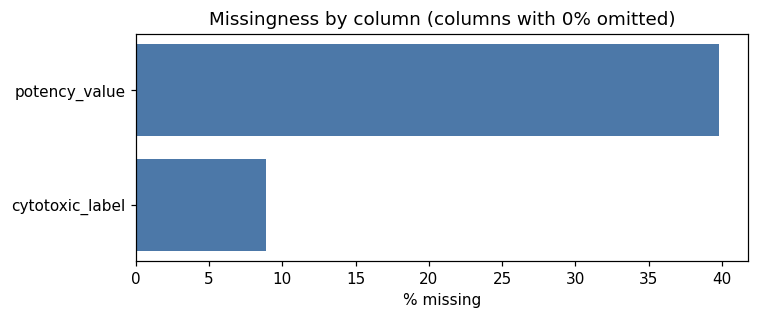

In [3]:
missing = df.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df) * 100).round(2)
missing = missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing.index, missing["pct_missing"], color="#4C78A8")
ax.set_xlabel("% missing")
ax.set_title("Missingness by column (columns with 0% omitted)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Missingness (%) by source, columns with any missing values:
         cytotoxic_label  potency_value
source                                 
Tox21              17.87          80.29
ToxCast             0.00           0.00


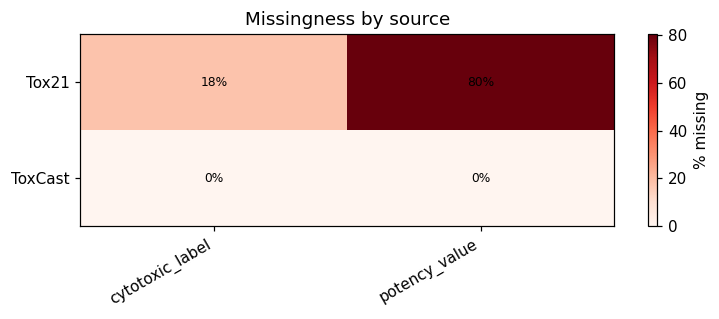

In [4]:
missing_by_source = df.groupby("source").apply(lambda g: g.isna().mean() * 100, include_groups=False)
missing_by_source = missing_by_source.loc[:, (missing_by_source != 0).any()]
print("Missingness (%) by source, columns with any missing values:")
print(missing_by_source.round(2))

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(missing_by_source.values, cmap="Reds", aspect="auto", vmin=0)
ax.set_xticks(range(len(missing_by_source.columns)))
ax.set_xticklabels(missing_by_source.columns, rotation=30, ha="right")
ax.set_yticks(range(len(missing_by_source.index)))
ax.set_yticklabels(missing_by_source.index)
for i in range(missing_by_source.shape[0]):
    for j in range(missing_by_source.shape[1]):
        ax.text(j, i, f"{missing_by_source.values[i, j]:.0f}%", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="% missing")
ax.set_title("Missingness by source")
plt.tight_layout()
plt.show()

In [5]:
n_dup_rows = df.duplicated().sum()
n_dup_smiles_within_source = df.duplicated(subset=["source", "canonical_smiles"]).sum()
n_dup_cid_within_source = df.duplicated(subset=["source", "cid"]).sum()
print(f"Fully duplicated rows: {n_dup_rows}")
print(f"Duplicate (source, canonical_smiles) pairs: {n_dup_smiles_within_source}")
print(f"Duplicate (source, cid) pairs: {n_dup_cid_within_source}")
print(f"Unique CIDs overall: {df['cid'].nunique()}  |  Unique SMILES overall: {df['canonical_smiles'].nunique()}")

Fully duplicated rows: 2
Duplicate (source, canonical_smiles) pairs: 241
Duplicate (source, cid) pairs: 43
Unique CIDs overall: 9147  |  Unique SMILES overall: 8828


## 3. Source and biological context breakdown

source   biological_context
Tox21    off-target-safety     7671
ToxCast  off-target-safety     7805
dtype: int64


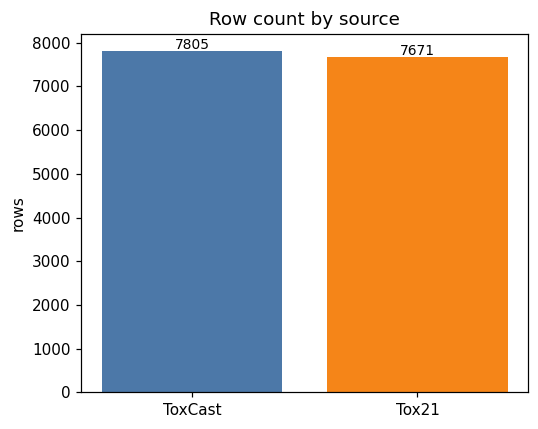

In [6]:
print(df.groupby(["source", "biological_context"]).size())

fig, ax = plt.subplots(figsize=(5, 4))
counts = df["source"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C78A8", "#F58518"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9)
ax.set_ylabel("rows")
ax.set_title("Row count by source")
plt.tight_layout()
plt.show()

## 4. Label distribution and class balance

`cytotoxic_label` is NaN for Tox21 rows PubChem's qHTS curve-fit called inconclusive across all
4 assays (never happens for ToxCast, whose pre-aggregated EPA table has no inconclusive
category) — those rows carry no usable ground truth and are excluded from every statistic below
that involves the label.

Labeled rows: 14105 / 15476  (1371 inconclusive/unusable)


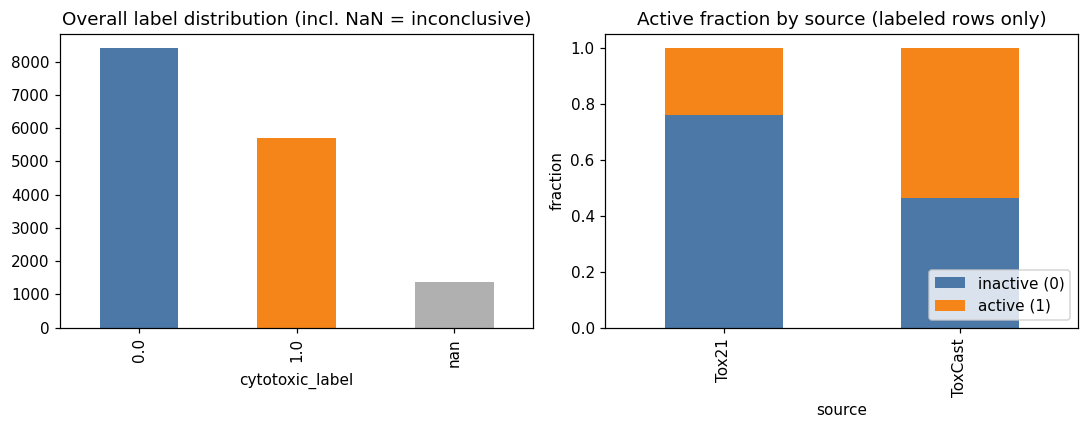

cytotoxic_label     0     1
source                     
Tox21            4788  1512
ToxCast          3621  4184


In [7]:
labeled = df.dropna(subset=["cytotoxic_label", "canonical_smiles"]).copy()
labeled["cytotoxic_label"] = labeled["cytotoxic_label"].astype(int)
print(f"Labeled rows: {len(labeled)} / {len(df)}  ({len(df) - len(labeled)} inconclusive/unusable)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["cytotoxic_label"].value_counts(dropna=False).sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#B0B0B0"]
)
axes[0].set_title("Overall label distribution (incl. NaN = inconclusive)")
axes[0].set_xlabel("cytotoxic_label")

ct_norm = pd.crosstab(labeled["source"], labeled["cytotoxic_label"], normalize="index")
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Active fraction by source (labeled rows only)")
axes[1].set_ylabel("fraction")
axes[1].legend(["inactive (0)", "active (1)"], loc="lower right")
plt.tight_layout()
plt.show()

ct = pd.crosstab(labeled["source"], labeled["cytotoxic_label"])
print(ct)

In [8]:
chi2, p, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Chi-square test (source vs. cytotoxic_label): chi2={chi2:.1f}, dof={dof}, p={p:.3e}")
print(f"Cramer's V (effect size): {cramers_v:.3f}")
print(
    "\nInterpretation: source and label are "
    + ("statistically dependent" if p < 0.05 else "not significantly dependent")
    + f" (Cramer's V of {cramers_v:.2f} is a "
    + ("large" if cramers_v > 0.5 else "moderate" if cramers_v > 0.3 else "small")
    + " effect for a 2x2 table) -- confirms `source` cannot be treated as a nuisance column."
)

Chi-square test (source vs. cytotoxic_label): chi2=1268.0, dof=1, p=1.001e-277
Cramer's V (effect size): 0.300

Interpretation: source and label are statistically dependent (Cramer's V of 0.30 is a small effect for a 2x2 table) -- confirms `source` cannot be treated as a nuisance column.


## 5. Cross-source compound overlap & label agreement

Beyond raw percent agreement: **Cohen's kappa** corrects for the agreement expected by chance
alone (given each source's own class balance), and **McNemar's exact test** asks whether
disagreements are systematically one-directional (e.g. ToxCast calling something active that
Tox21 calls inactive, more often than the reverse) rather than symmetric noise.

In [9]:
sources = labeled["source"].unique().tolist()
for i in range(len(sources)):
    for j in range(i + 1, len(sources)):
        a, b = sources[i], sources[j]
        cids_a = set(labeled.loc[labeled["source"] == a, "cid"])
        cids_b = set(labeled.loc[labeled["source"] == b, "cid"])
        overlap = cids_a & cids_b
        print(f"{a} ({len(cids_a)}) vs {b} ({len(cids_b)}): {len(overlap)} shared CIDs")

pivot = labeled.pivot_table(index="cid", columns="source", values="cytotoxic_label", aggfunc="first")
pair_cols = [c for c in pivot.columns if c in sources]
both = pivot.dropna(subset=pair_cols)
a_labels, b_labels = both[pair_cols[0]].astype(int), both[pair_cols[1]].astype(int)

agree = (a_labels == b_labels).mean()
print(f"\nOf {len(both)} compounds labeled in both {pair_cols[0]} and {pair_cols[1]}: {agree:.1%} raw agreement")

Tox21 (6300) vs ToxCast (7762): 5155 shared CIDs

Of 5155 compounds labeled in both Tox21 and ToxCast: 72.3% raw agreement


In [10]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(a_labels, b_labels)

# 2x2 contingency of the paired calls, then exact McNemar's test on the discordant pairs
both_ct = pd.crosstab(a_labels, b_labels)
print(both_ct)
b_disc = both_ct.loc[0, 1] if (0 in both_ct.index and 1 in both_ct.columns) else 0
c_disc = both_ct.loc[1, 0] if (1 in both_ct.index and 0 in both_ct.columns) else 0
mcnemar_p = stats.binomtest(min(b_disc, c_disc), b_disc + c_disc, p=0.5).pvalue if (b_disc + c_disc) > 0 else float("nan")

print(f"\nCohen's kappa: {kappa:.3f}  "
      f"({'slight' if kappa < 0.2 else 'fair' if kappa < 0.4 else 'moderate' if kappa < 0.6 else 'substantial' if kappa < 0.8 else 'almost perfect'} "
      "agreement beyond chance)")
print(f"Discordant pairs: {pair_cols[0]}=0/{pair_cols[1]}=1 -> {b_disc},  {pair_cols[0]}=1/{pair_cols[1]}=0 -> {c_disc}")
print(f"McNemar's exact test p-value: {mcnemar_p:.3e}  "
      + ("-- disagreements are NOT symmetric (systematic source bias)" if mcnemar_p < 0.05
         else "-- disagreements are consistent with symmetric noise"))

ToxCast     0     1
Tox21              
0        2528  1412
1          16  1199



Cohen's kappa: 0.450  (moderate agreement beyond chance)
Discordant pairs: Tox21=0/ToxCast=1 -> 1412,  Tox21=1/ToxCast=0 -> 16
McNemar's exact test p-value: 0.000e+00  -- disagreements are NOT symmetric (systematic source bias)


## 6. Molecular weight: distribution & statistical comparison

          count    mean     std    min     25%     50%     75%     max  skew  \
source                                                                         
Tox21    6300.0  263.05  147.45  30.03  158.28  229.07  331.58  1550.2  2.02   
ToxCast  7805.0  285.81  181.59  22.99  168.19  245.66  354.50  3326.8  3.48   

         kurtosis  
source             
Tox21        7.96  
ToxCast     28.25  


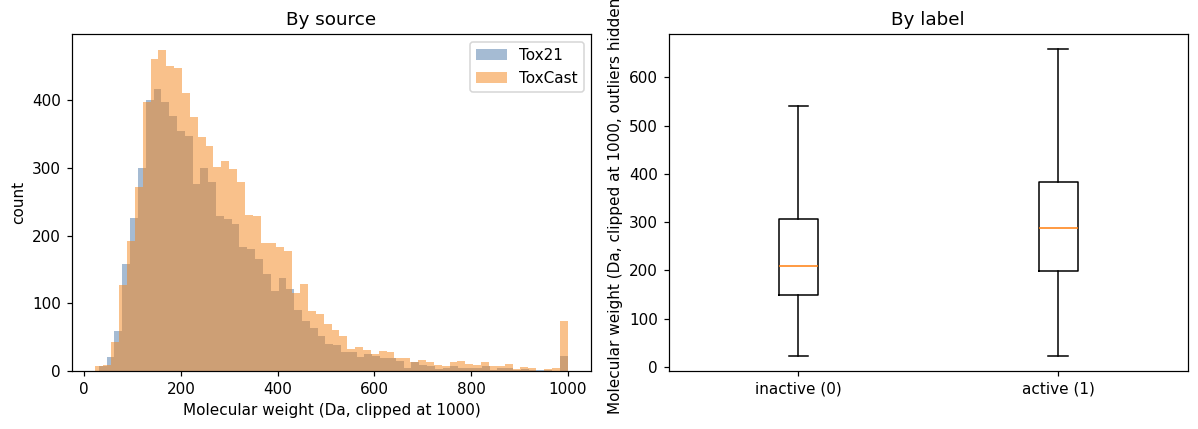

In [11]:
desc_stats = labeled.groupby("source")["molecular_weight"].describe()
desc_stats["skew"] = labeled.groupby("source")["molecular_weight"].apply(lambda s: stats.skew(s.dropna()))
desc_stats["kurtosis"] = labeled.groupby("source")["molecular_weight"].apply(lambda s: stats.kurtosis(s.dropna()))
print(desc_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for src, color in zip(labeled["source"].unique(), ["#4C78A8", "#F58518"]):
    subset = labeled.loc[labeled["source"] == src, "molecular_weight"].dropna()
    axes[0].hist(subset.clip(upper=1000), bins=60, alpha=0.5, label=src, color=color)
axes[0].set_xlabel("Molecular weight (Da, clipped at 1000)")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("By source")

box_data = [labeled.loc[labeled["cytotoxic_label"] == c, "molecular_weight"].clip(upper=1000) for c in (0, 1)]
axes[1].boxplot(box_data, tick_labels=["inactive (0)", "active (1)"], showfliers=False)
axes[1].set_ylabel("Molecular weight (Da, clipped at 1000, outliers hidden)")
axes[1].set_title("By label")
plt.tight_layout()
plt.show()

In [12]:
tox21_mw = labeled.loc[labeled["source"] == "Tox21", "molecular_weight"].dropna()
toxcast_mw = labeled.loc[labeled["source"] == "ToxCast", "molecular_weight"].dropna()
u_stat, p_source = stats.mannwhitneyu(tox21_mw, toxcast_mw, alternative="two-sided")
rank_biserial = 1 - (2 * u_stat) / (len(tox21_mw) * len(toxcast_mw))
print(f"Mann-Whitney U (Tox21 vs ToxCast MW): p={p_source:.3e}, rank-biserial r={rank_biserial:.3f}")

inactive_mw = labeled.loc[labeled["cytotoxic_label"] == 0, "molecular_weight"].dropna()
active_mw = labeled.loc[labeled["cytotoxic_label"] == 1, "molecular_weight"].dropna()
u_stat2, p_label = stats.mannwhitneyu(inactive_mw, active_mw, alternative="two-sided")
rank_biserial2 = 1 - (2 * u_stat2) / (len(inactive_mw) * len(active_mw))
print(f"Mann-Whitney U (inactive vs active MW): p={p_label:.3e}, rank-biserial r={rank_biserial2:.3f}")
print(f"Median MW: inactive={inactive_mw.median():.1f}  active={active_mw.median():.1f}")

Mann-Whitney U (Tox21 vs ToxCast MW): p=9.651e-13, rank-biserial r=0.070


Mann-Whitney U (inactive vs active MW): p=2.526e-196, rank-biserial r=0.296
Median MW: inactive=208.3  active=287.3


## 7. Potency (AC50) analysis

`potency_value` (µM) is only populated for compounds called active in at least one assay — by
construction it's missing for every inactive compound, so this section is restricted to actives.

          count     mean      std    min    25%     50%       75%       max
source                                                                     
Tox21    1512.0   20.388   15.818  0.001   6.74    19.4    27.536    70.228
ToxCast  7805.0  642.859  466.702  0.014  40.00  1000.0  1000.000  1000.000


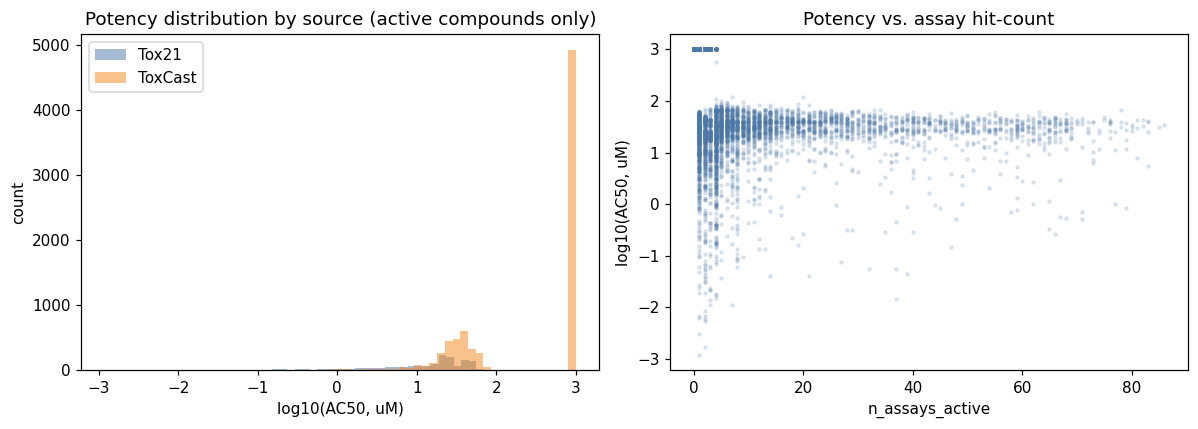

Spearman correlation (n_assays_active vs log10 potency): rho=-0.739, p=0.000e+00  -- compounds active in more assays tend to be more potent (lower AC50)


In [13]:
potent = labeled.dropna(subset=["potency_value"]).copy()
potent = potent[potent["potency_value"] > 0]
potent["log10_potency"] = np.log10(potent["potency_value"])
print(potent.groupby("source")["potency_value"].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for src, color in zip(potent["source"].unique(), ["#4C78A8", "#F58518"]):
    subset = potent.loc[potent["source"] == src, "log10_potency"]
    axes[0].hist(subset, bins=50, alpha=0.5, label=src, color=color)
axes[0].set_xlabel("log10(AC50, uM)")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Potency distribution by source (active compounds only)")

axes[1].scatter(potent["n_assays_active"], potent["log10_potency"], s=4, alpha=0.15, color="#4C78A8")
axes[1].set_xlabel("n_assays_active")
axes[1].set_ylabel("log10(AC50, uM)")
axes[1].set_title("Potency vs. assay hit-count")
plt.tight_layout()
plt.show()

rho, p_rho = stats.spearmanr(potent["n_assays_active"], potent["log10_potency"])
print(f"Spearman correlation (n_assays_active vs log10 potency): rho={rho:.3f}, p={p_rho:.3e}  "
      + ("-- compounds active in more assays tend to be more potent (lower AC50)" if rho < 0 and p_rho < 0.05
         else "-- no strong monotonic relationship"))

## 8. Assay coverage

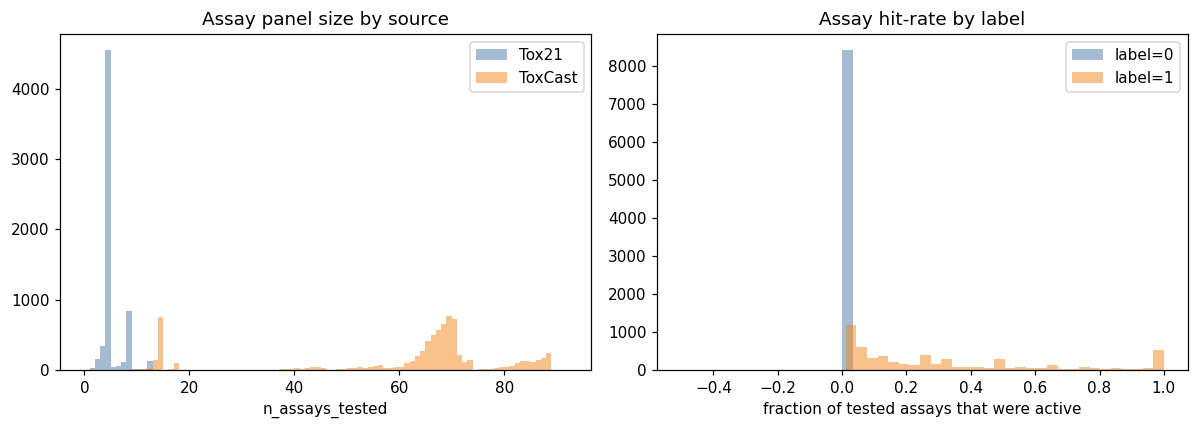

        n_assays_tested                                             \
                  count   mean    std  min   25%   50%   75%   max   
source                                                               
Tox21            6300.0   4.71   1.93  1.0   4.0   4.0   4.0  26.0   
ToxCast          7805.0  61.26  20.89  1.0  62.0  67.0  70.0  91.0   

        n_assays_active                                         
                  count  mean    std  min  25%  50%  75%   max  
source                                                          
Tox21            6300.0  0.56   1.31  0.0  0.0  0.0  0.0  12.0  
ToxCast          7805.0  7.78  15.05  0.0  0.0  1.0  7.0  86.0  


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for src, color in zip(labeled["source"].unique(), ["#4C78A8", "#F58518"]):
    subset = labeled.loc[labeled["source"] == src, "n_assays_tested"]
    axes[0].hist(subset, bins=range(0, int(labeled["n_assays_tested"].max()) + 2), alpha=0.5, label=src, color=color)
axes[0].set_xlabel("n_assays_tested")
axes[0].legend()
axes[0].set_title("Assay panel size by source")

labeled["frac_active"] = labeled["n_assays_active"] / labeled["n_assays_tested"].replace(0, np.nan)
for label_val, color in ((0, "#4C78A8"), (1, "#F58518")):
    subset = labeled.loc[labeled["cytotoxic_label"] == label_val, "frac_active"].dropna()
    axes[1].hist(subset, bins=30, alpha=0.5, label=f"label={label_val}", color=color)
axes[1].set_xlabel("fraction of tested assays that were active")
axes[1].legend()
axes[1].set_title("Assay hit-rate by label")
plt.tight_layout()
plt.show()

print(labeled.groupby("source")[["n_assays_tested", "n_assays_active"]].describe().round(2))

## 9. Elemental composition & halogen content

Parsed directly from `molecular_formula` (e.g. `C6H3Cl3` -> {C:6, H:3, Cl:3}) rather than
re-deriving from SMILES -- cheap and exact.

In [15]:
def parse_formula(formula):
    return {el: int(count) if count else 1 for el, count in re.findall(r"([A-Z][a-z]?)(\d*)", formula) if el}

formula_counts = labeled["molecular_formula"].apply(parse_formula)
all_elements = sorted({el for d in formula_counts for el in d})
print(f"Elements observed: {all_elements}")

element_df = pd.DataFrame([{el: d.get(el, 0) for el in all_elements} for d in formula_counts], index=labeled.index)
HALOGENS = [e for e in ["F", "Cl", "Br", "I"] for e in [e] if e in all_elements]
labeled["has_halogen"] = (element_df[HALOGENS].sum(axis=1) > 0) if HALOGENS else False
labeled["n_heteroatoms_formula"] = element_df.drop(columns=[c for c in ("C", "H") if c in element_df.columns]).sum(axis=1)

print(f"\n{labeled['has_halogen'].mean():.1%} of compounds contain at least one halogen (F/Cl/Br/I)")
halogen_ct = pd.crosstab(labeled["has_halogen"], labeled["cytotoxic_label"])
print(halogen_ct)
chi2, p, dof, _ = stats.chi2_contingency(halogen_ct)
print(f"Chi-square (halogen presence vs. label): chi2={chi2:.1f}, p={p:.3e}")

Elements observed: ['Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Cl', 'Co', 'Cr', 'Cu', 'Dy', 'Eu', 'F', 'Fe', 'Gd', 'Ge', 'H', 'Hg', 'I', 'In', 'K', 'Li', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nd', 'Ni', 'O', 'P', 'Pb', 'Pd', 'Pt', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sn', 'Sr', 'Ti', 'Tl', 'V', 'Yb', 'Zn', 'Zr']

31.9% of compounds contain at least one halogen (F/Cl/Br/I)
cytotoxic_label     0     1
has_halogen                
False            6007  3598
True             2402  2098
Chi-square (halogen presence vs. label): chi2=106.5, p=5.797e-25


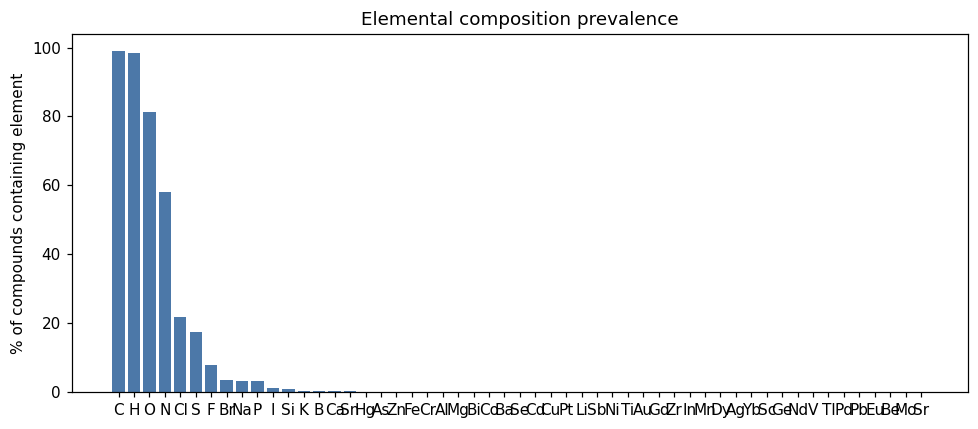

In [16]:
element_freq = (element_df > 0).mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(element_freq.index, element_freq.values, color="#4C78A8")
ax.set_ylabel("% of compounds containing element")
ax.set_title("Elemental composition prevalence")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. RDKit physicochemical descriptors: distributions & association with label

For each descriptor: a **Mann-Whitney U test** (active vs. inactive; non-parametric, robust to
the skewed distributions typical of these descriptors) plus a **rank-biserial correlation** as
effect size, so the table below is sorted by how strongly -- not just how significantly -- each
property associates with cytotoxicity (with ~13k rows, even trivial effects reach p < 0.05, so
effect size is what actually matters here).

In [17]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

DESCRIPTOR_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumHeteroatoms": Descriptors.NumHeteroatoms,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "NumAliphaticRings": Descriptors.NumAliphaticRings,
}

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {name: f(mol) for name, f in DESCRIPTOR_FUNCS.items()}

unique_smiles = labeled["canonical_smiles"].unique()
desc_cache = {s: compute_descriptors(s) for s in unique_smiles}
n_failed = sum(v is None for v in desc_cache.values())
print(f"Computed descriptors for {len(unique_smiles) - n_failed}/{len(unique_smiles)} unique structures")

desc_df = labeled["canonical_smiles"].map(desc_cache).apply(pd.Series)
desc_df.index = labeled.index
labeled_desc = pd.concat([labeled, desc_df], axis=1).dropna(subset=list(DESCRIPTOR_FUNCS.keys()))
print(f"Rows with usable descriptors: {len(labeled_desc)}")

Computed descriptors for 8621/8621 unique structures


Rows with usable descriptors: 14105


In [18]:
rows = []
for name in DESCRIPTOR_FUNCS:
    inactive_vals = labeled_desc.loc[labeled_desc["cytotoxic_label"] == 0, name]
    active_vals = labeled_desc.loc[labeled_desc["cytotoxic_label"] == 1, name]
    u_stat, p_val = stats.mannwhitneyu(inactive_vals, active_vals, alternative="two-sided")
    r = 1 - (2 * u_stat) / (len(inactive_vals) * len(active_vals))
    rows.append({
        "descriptor": name,
        "median_inactive": inactive_vals.median(),
        "median_active": active_vals.median(),
        "rank_biserial_r": r,
        "p_value": p_val,
    })

assoc_table = pd.DataFrame(rows).sort_values("rank_biserial_r", key=abs, ascending=False)
print(assoc_table.round(4).to_string(index=False))

       descriptor  median_inactive  median_active  rank_biserial_r  p_value
          MolLogP           1.6992         3.1432           0.3986   0.0000
            MolWt         208.2610       287.3515           0.2962   0.0000
   HeavyAtomCount          14.0000        19.0000           0.2905   0.0000
        RingCount           1.0000         2.0000           0.2558   0.0000
 NumAromaticRings           1.0000         1.0000           0.2409   0.0000
     FractionCSP3           0.4667         0.3810          -0.1056   0.0000
NumRotatableBonds           3.0000         3.0000           0.1004   0.0000
NumAliphaticRings           0.0000         0.0000           0.0742   0.0000
   NumHeteroatoms           4.0000         4.0000           0.0451   0.0000
             TPSA          46.6100        43.7000          -0.0426   0.0000
       NumHDonors           1.0000         1.0000          -0.0410   0.0000
    NumHAcceptors           3.0000         3.0000           0.0299   0.0022


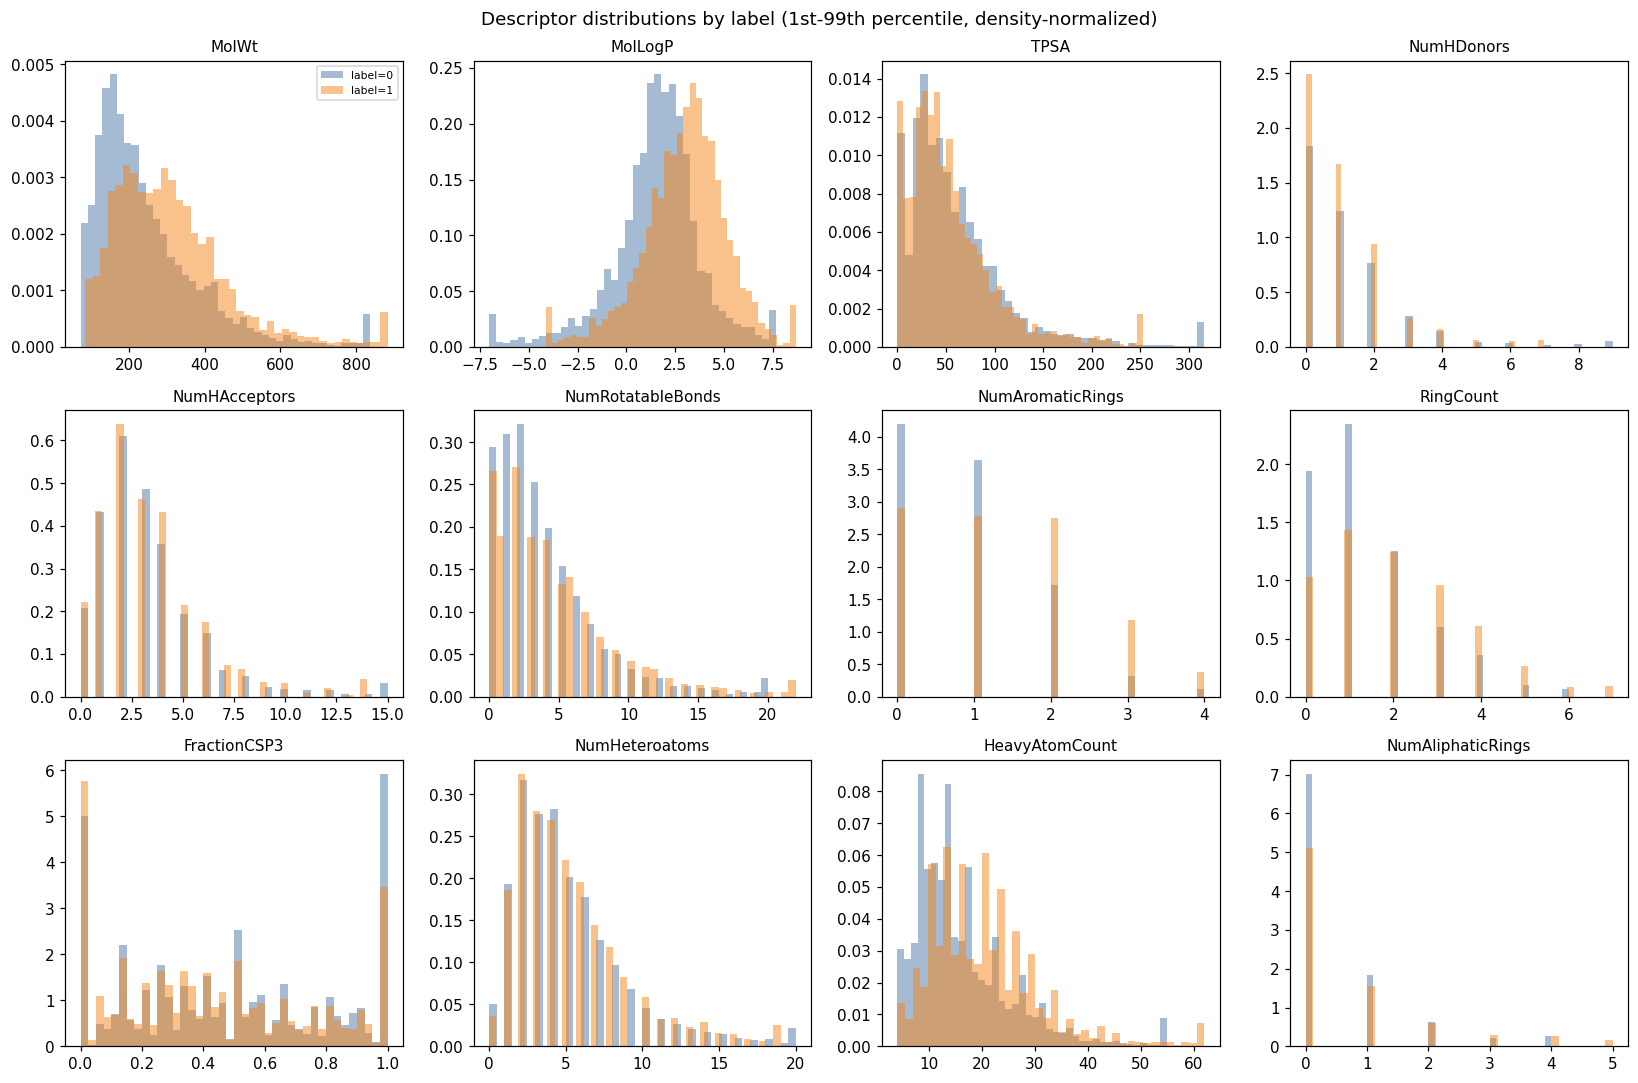

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for ax, name in zip(axes.flat, DESCRIPTOR_FUNCS):
    for label_val, color in ((0, "#4C78A8"), (1, "#F58518")):
        vals = labeled_desc.loc[labeled_desc["cytotoxic_label"] == label_val, name]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.5, density=True, color=color, label=f"label={label_val}")
    ax.set_title(name, fontsize=10)
axes.flat[0].legend(fontsize=7)
for ax in axes.flat[len(DESCRIPTOR_FUNCS):]:
    ax.set_visible(False)
fig.suptitle("Descriptor distributions by label (1st-99th percentile, density-normalized)")
plt.tight_layout()
plt.show()

## 11. Descriptor correlation structure

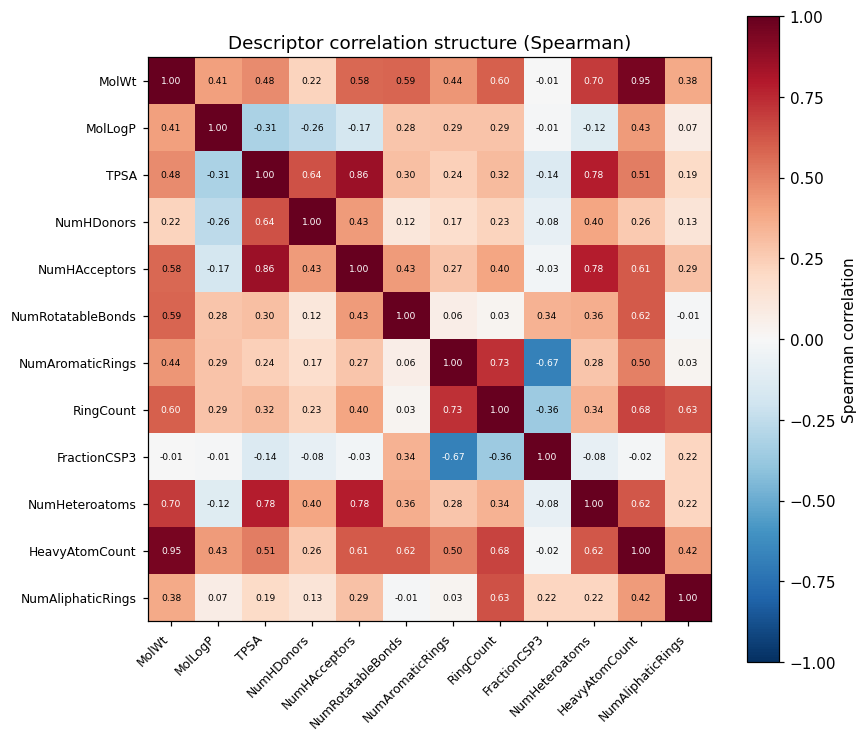

In [20]:
corr = labeled_desc[list(DESCRIPTOR_FUNCS.keys())].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6,
                 color="white" if abs(corr.values[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Descriptor correlation structure (Spearman)")
plt.tight_layout()
plt.show()

## 12. Lipinski's Rule of Five / drug-likeness

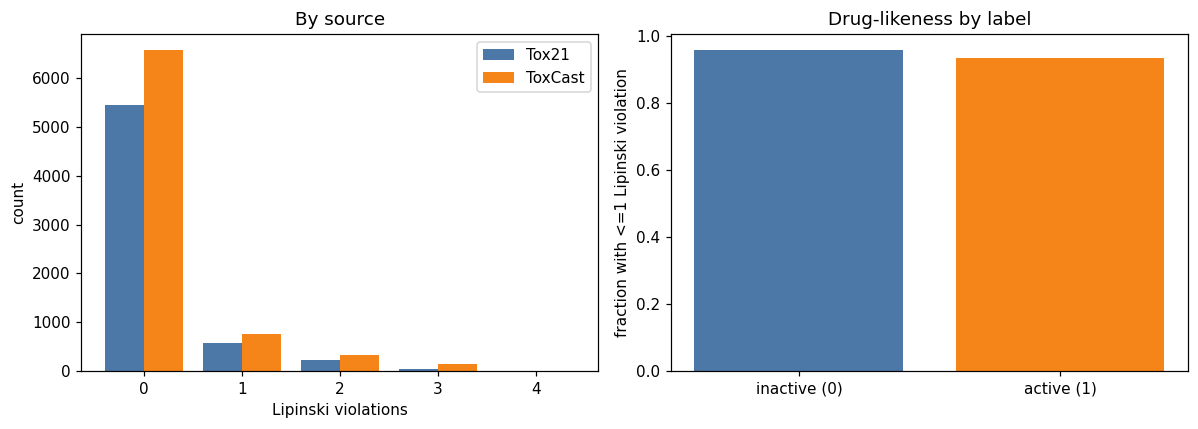

Drug-like (<=1 violation): 94.8% overall
          count  mean   std  min  25%  50%  75%  max
source                                              
Tox21    6300.0  0.18  0.51  0.0  0.0  0.0  0.0  4.0
ToxCast  7805.0  0.24  0.62  0.0  0.0  0.0  0.0  4.0


In [21]:
labeled_desc["lipinski_violations"] = (
    (labeled_desc["MolWt"] > 500).astype(int)
    + (labeled_desc["MolLogP"] > 5).astype(int)
    + (labeled_desc["NumHDonors"] > 5).astype(int)
    + (labeled_desc["NumHAcceptors"] > 10).astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
violin_data = [labeled_desc.loc[labeled_desc["source"] == s, "lipinski_violations"] for s in labeled_desc["source"].unique()]
axes[0].hist(violin_data, bins=range(6), label=labeled_desc["source"].unique(), color=["#4C78A8", "#F58518"], align="left")
axes[0].set_xlabel("Lipinski violations")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("By source")

drug_like_by_label = labeled_desc.groupby("cytotoxic_label")["lipinski_violations"].apply(lambda s: (s <= 1).mean())
axes[1].bar(["inactive (0)", "active (1)"], drug_like_by_label.values, color=["#4C78A8", "#F58518"])
axes[1].set_ylabel("fraction with <=1 Lipinski violation")
axes[1].set_title("Drug-likeness by label")
plt.tight_layout()
plt.show()

print(f"Drug-like (<=1 violation): {(labeled_desc['lipinski_violations'] <= 1).mean():.1%} overall")
print(labeled_desc.groupby("source")["lipinski_violations"].describe().round(2))

## 13. Bemis-Murcko scaffold diversity

Generic ring-system skeletons (side chains stripped) as a proxy for "chemical class." Diversity
is summarized two ways: the **Shannon index** (H = -sum p_i * ln(p_i), higher = more evenly
spread across many scaffolds) and the **Gini-Simpson index** (1 - sum p_i^2, the probability two
randomly drawn compounds have different scaffolds) -- both computed per source so it's clear
whether Tox21 and ToxCast draw from comparably diverse chemical space.

In [22]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    s = Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    return s if s else "(acyclic)"

scaffold_cache = {s: get_scaffold(s) for s in unique_smiles}
labeled["scaffold"] = labeled["canonical_smiles"].map(scaffold_cache)

def diversity_stats(scaffolds):
    counts = pd.Series(scaffolds).value_counts()
    p = counts / counts.sum()
    shannon = -(p * np.log(p)).sum()
    gini_simpson = 1 - (p ** 2).sum()
    return {
        "n_compounds": len(scaffolds),
        "n_scaffolds": len(counts),
        "n_singletons": int((counts == 1).sum()),
        "shannon": shannon,
        "gini_simpson": gini_simpson,
    }

overall = diversity_stats(labeled["scaffold"])
by_source = {src: diversity_stats(labeled.loc[labeled["source"] == src, "scaffold"]) for src in labeled["source"].unique()}
diversity_df = pd.DataFrame({"overall": overall, **by_source}).T
print(diversity_df.round(3))

         n_compounds  n_scaffolds  n_singletons  shannon  gini_simpson
overall      14105.0       2371.0         787.0    4.893         0.901
Tox21         6300.0       1722.0        1310.0    4.659         0.892
ToxCast       7805.0       2172.0        1602.0    4.994         0.908


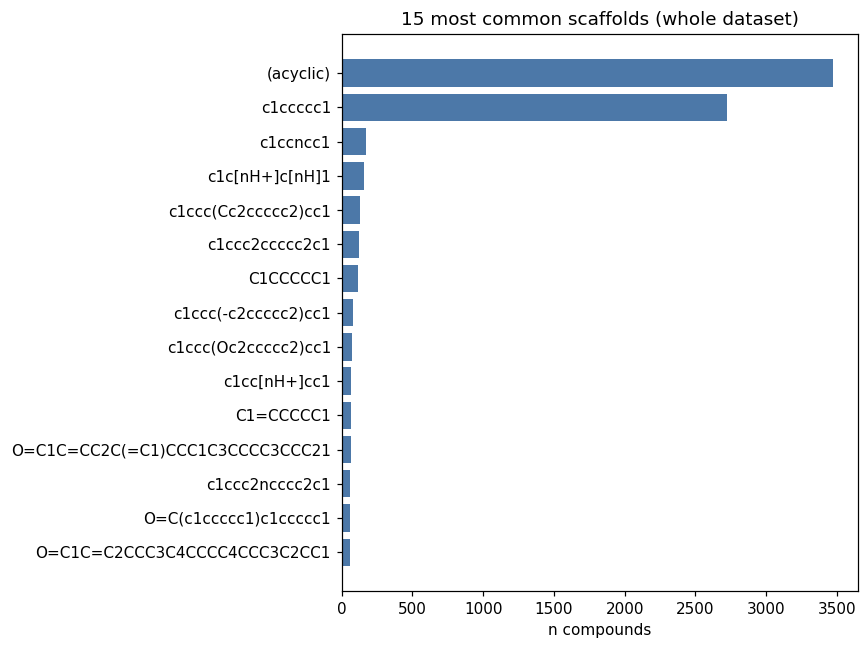

787 / 2371 scaffolds are singletons (33.2%)


In [23]:
scaffold_counts = labeled["scaffold"].value_counts()
top15 = scaffold_counts.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"{s[:35]}{'...' if len(s) > 35 else ''}" for s in top15.index]
ax.barh(labels, top15.values, color="#4C78A8")
ax.invert_yaxis()
ax.set_xlabel("n compounds")
ax.set_title("15 most common scaffolds (whole dataset)")
plt.tight_layout()
plt.show()

print(f"{(scaffold_counts == 1).sum()} / {len(scaffold_counts)} scaffolds are singletons "
      f"({(scaffold_counts == 1).sum() / len(scaffold_counts):.1%})")

## 14. Chemical space visualization

Morgan fingerprints (radius=2, 2048 bits, same as `eda_and_baselines.ipynb`) reduced to 2D via
PCA (fast, linear, preserves global variance) and via t-SNE on the top-50 PCA components (slower,
non-linear, better at revealing local cluster structure) -- each colored by source and by label.

In [24]:
from sklearn.decomposition import PCA
from rdkit.Chem import rdFingerprintGenerator

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(fp_gen.GetFingerprint(mol))

fp_cache = {s: smiles_to_fp(s) for s in unique_smiles}
labeled["_fp"] = labeled["canonical_smiles"].map(fp_cache)
chem_space_df = labeled.dropna(subset=["_fp"]).reset_index(drop=True)
X_fp = np.stack(chem_space_df["_fp"].values)
print(f"Fingerprint matrix: {X_fp.shape}")

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_fp)
print(f"Variance explained by first 2 / 50 components: "
      f"{pca.explained_variance_ratio_[:2].sum():.1%} / {pca.explained_variance_ratio_.sum():.1%}")

Fingerprint matrix: (14105, 2048)


Variance explained by first 2 / 50 components: 7.6% / 42.0%


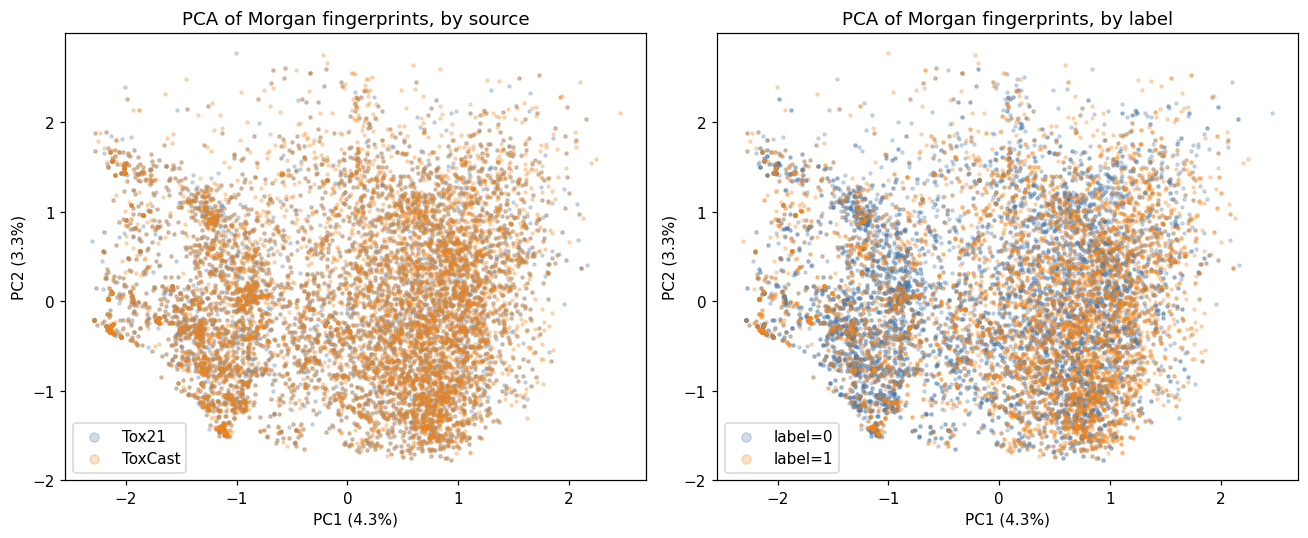

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
source_colors = {"Tox21": "#4C78A8", "ToxCast": "#F58518"}
for src, color in source_colors.items():
    mask = (chem_space_df["source"] == src).values
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.25, color=color, label=src)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA of Morgan fingerprints, by source")
axes[0].legend(markerscale=3)

label_mask = chem_space_df["cytotoxic_label"].notna().values
label_colors = {0: "#4C78A8", 1: "#F58518"}
for lab, color in label_colors.items():
    mask = label_mask & (chem_space_df["cytotoxic_label"] == lab).values
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.25, color=color, label=f"label={lab}")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PCA of Morgan fingerprints, by label")
axes[1].legend(markerscale=3)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_pca)
print("t-SNE done")

t-SNE done


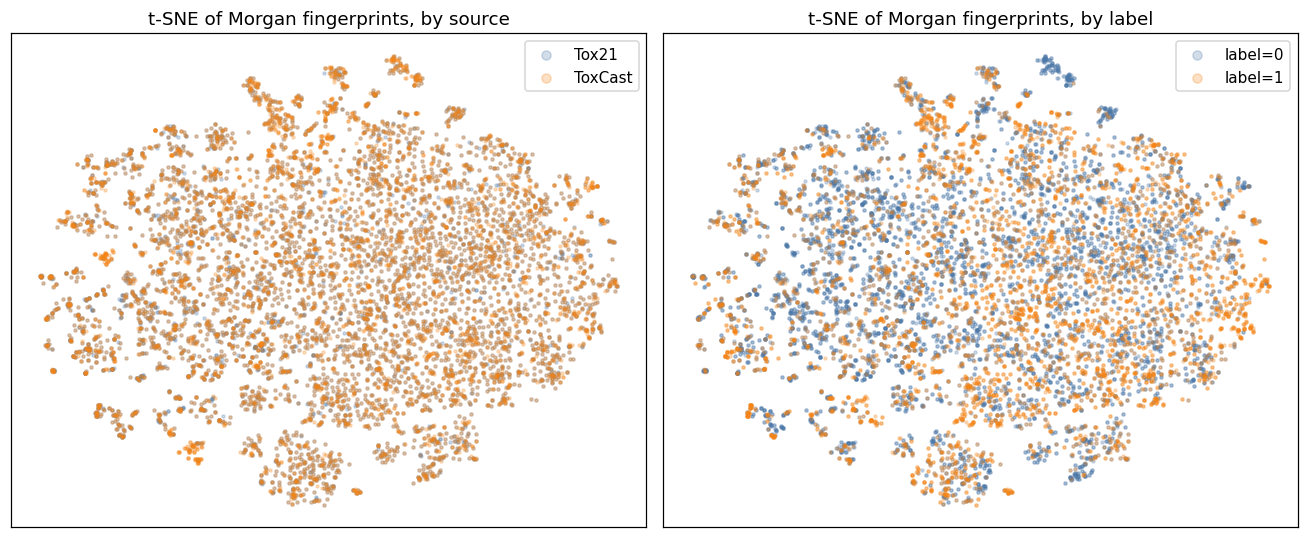

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for src, color in source_colors.items():
    mask = (chem_space_df["source"] == src).values
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=4, alpha=0.25, color=color, label=src)
axes[0].set_title("t-SNE of Morgan fingerprints, by source")
axes[0].legend(markerscale=3)
axes[0].set_xticks([]); axes[0].set_yticks([])

for lab, color in label_colors.items():
    mask = label_mask & (chem_space_df["cytotoxic_label"] == lab).values
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=4, alpha=0.25, color=color, label=f"label={lab}")
axes[1].set_title("t-SNE of Morgan fingerprints, by label")
axes[1].legend(markerscale=3)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.show()

## 15. Summary takeaways

**Data quality**
- 14,105 / 15,476 rows are usable (1,371 unlabeled Tox21 rows — every assay called "inconclusive" — plus a handful with no parseable SMILES).
- 241 rows share a `(source, canonical_smiles)` pair and 43 share `(source, cid)` — worth a dedup pass before any per-row (rather than per-compound) analysis, since these aren't just cross-source duplicates (already handled separately) but same-source repeats.
- **ToxCast's `potency_value` is heavily right-censored**: median AND 75th percentile both sit exactly at 1000 µM (the assay's apparent reporting ceiling), vs. Tox21's actives spanning a real 6.7–27.5 µM interquartile range. Treat ToxCast potency as "≥ this weak" for a large share of its actives, not a precise AC50 — this also explains why it looked odd in earlier sections' potency plots.

**Source and label are entangled, and the disagreement isn't noise**
- Source significantly predicts label (χ²=1268, p≈0, Cramér's V=0.30) — Tox21 is 24% active, ToxCast 54% active.
- Of 5,155 compounds tested in both, raw agreement is 72.3%, but Cohen's κ=0.45 (only "moderate" once chance agreement is removed) — and McNemar's test confirms the disagreements are **not symmetric noise** (p≈0): ToxCast calls a compound active when Tox21 calls it inactive 1,412 times, vs. only 16 times the other way around. That ~88:1 asymmetry tracks directly with panel size — ToxCast screens ~61 assays per compound on average vs. Tox21's ~4–5, so it has far more chances to register a hit. The two labels are measuring "hit anywhere in a wide safety panel" vs. "hit in a narrow, purpose-built viability panel," not the same underlying property.

**Chemistry does associate with the label — lipophilicity most of all**
Ranking every RDKit descriptor by rank-biserial effect size (not just p-value — at n≈14k, even trivial effects hit p<0.05):
- **MolLogP** is the strongest single predictor (r=0.40, median 3.14 for active vs. 1.70 for inactive) — more lipophilic compounds are more likely to be flagged cytotoxic, consistent with membrane-permeability-driven toxicity.
- MolWt, HeavyAtomCount, RingCount, and NumAromaticRings all point the same direction with moderate effect sizes (r≈0.24–0.30): bigger, more ring-rich, more aromatic compounds skew active.
- FractionCSP3 is moderately *negative* (r=-0.11) — the mirror image of the ring/aromaticity findings (more sp3 = less flat/aromatic = less likely active).
- H-bonding and polarity descriptors (TPSA, NumHDonors, NumHAcceptors, NumHeteroatoms) all have negligible effect sizes (|r|<0.05) despite technically significant p-values — a clean illustration of significance vs. effect size at this sample size.
- Halogenation shows a real but modest bump: 37.5% active among non-halogenated compounds vs. 46.6% among halogenated ones (χ²=106.5, p=6e-25).

**Chemical space is broad and not source-segregated**
- 2,371 distinct Bemis-Murcko scaffolds across 14,105 compounds; Gini-Simpson index 0.90 (90% chance two random compounds differ in scaffold) — this is a chemically diverse collection, not a few chemotype families repeated many times, and Tox21/ToxCast are comparably diverse (Gini-Simpson 0.89 vs. 0.91).
- 94.8% of compounds satisfy Lipinski's Rule of Five with ≤1 violation — both sources look like small-molecule/drug-like libraries, not the targeted, often Ro5-violating oncology compounds expected once GDSC is added — worth re-running this section after that to see the shift.
- PCA on the 2048-bit fingerprints captures only 7.6% of variance in 2 components (42% in 50) — fingerprint space is inherently high-dimensional with no dominant low-rank structure, so the PCA/t-SNE scatter plots above are best read qualitatively (cluster shape, source/label mixing) rather than as a faithful low-dimensional summary.